In [2]:
import pandas as pd

df = pd.read_csv("sleepedf_SC_merged_epochs.csv")
df.head()


,recording_id,epoch,epoch_start_sec,epoch_end_sec,sleep_stage,EEG Fpz-Cz_mean,EEG Fpz-Cz_std,EEG Fpz-Cz_rms,EEG Pz-Oz_mean,EEG Pz-Oz_std,EEG Pz-Oz_rms,EOG horizontal_mean,EOG horizontal_std,EOG horizontal_rms,EMG submental_mean,EMG submental_std,EMG submental_rms,psg_file,hyp_file
0,SC4001E0,0,0,30,W,4.087560e-07,0.000036,0.000036,-3.101700e-07,0.000007,0.000007,-2.633174e-07,0.000096,0.000096,0.000003,7.510625e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf
1,SC4001E0,1,30,60,W,-5.228151e-07,0.000026,0.000026,-4.021419e-07,0.000009,0.000009,4.579554e-06,0.000106,0.000106,0.000003,8.407522e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf
2,SC4001E0,2,60,90,W,9.948366e-07,0.000032,0.000032,-3.691600e-07,0.000009,0.000009,6.340643e-08,0.000098,0.000098,0.000003,6.734637e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf
3,SC4001E0,3,90,120,W,-2.231795e-07,0.000018,0.000018,-1.439807e-07,0.000009,0.000009,-2.184729e-07,0.000028,0.000028,0.000003,6.755479e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf
4,SC4001E0,4,120,150,W,1.761055e-07,0.000017,0.000017,-1.639426e-07,0.000010,0.000010,1.876075e-06,0.000019,0.000019,0.000003,6.240385e-08,0.000003,SC4001E0-PSG.edf,SC4001EC-Hypnogram.edf


In [3]:
df["sleep_stage"].value_counts()


sleep_stage
W      285433
N2      69132
REM     25835
N1      21522
N3      13039
Name: count, dtype: int64

<Axes: title={'center': 'Distribution of Sleep Stages'}, xlabel='sleep_stage', ylabel='Number of Epochs'>

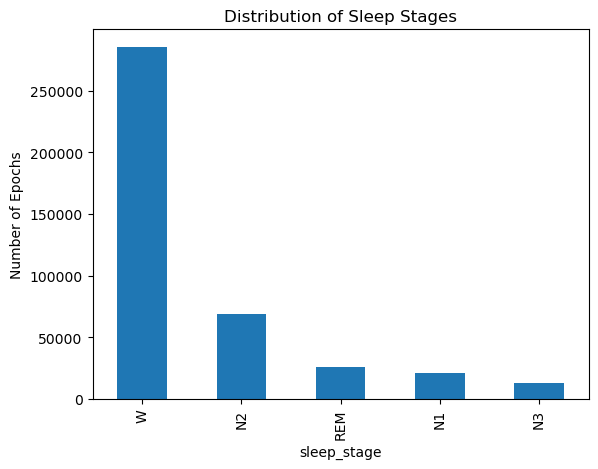

In [4]:
df["sleep_stage"].value_counts().plot(
    kind="bar",
    title="Distribution of Sleep Stages",
    ylabel="Number of Epochs"
)


In [5]:
df.isna().sum().sort_values(ascending=False).head(15)


recording_id           0
EEG Pz-Oz_rms          0
psg_file               0
EMG submental_rms      0
EMG submental_std      0
EMG submental_mean     0
EOG horizontal_rms     0
EOG horizontal_std     0
EOG horizontal_mean    0
EEG Pz-Oz_std          0
epoch                  0
EEG Pz-Oz_mean         0
EEG Fpz-Cz_rms         0
EEG Fpz-Cz_std         0
EEG Fpz-Cz_mean        0
dtype: int64

In [6]:
df.describe().T[["mean", "std", "min", "max"]].head(10)


,mean,std,min,max
epoch,1.360026e+03,789.531923,0.000000e+00,2879.000000
epoch_start_sec,4.080078e+04,23685.957683,0.000000e+00,86370.000000
epoch_end_sec,4.083078e+04,23685.957683,3.000000e+01,86400.000000
EEG Fpz-Cz_mean,6.481989e-08,0.000003,-3.371427e-05,0.000024
EEG Fpz-Cz_std,2.313722e-05,0.000012,6.666881e-07,0.000132
EEG Fpz-Cz_rms,2.330651e-05,0.000012,6.767322e-07,0.000132
EEG Pz-Oz_mean,-3.719472e-09,0.000002,-2.412127e-05,0.000020
EEG Pz-Oz_std,1.062203e-05,0.000007,6.180246e-07,0.000127
EEG Pz-Oz_rms,1.074147e-05,0.000007,7.017549e-07,0.000127
EOG horizontal_mean,-1.802994e-06,0.000019,-1.995541e-04,0.000054


In [7]:
drop_cols = ["epoch", "epoch_start_sec", "epoch_end_sec"]


## Steps for RNN

- Map sleep-stage labels (W, N1, N2, N3, REM) to integers and remove invalid labels.

- Split the dataset into training and testing sets by recording_id.

- Remove non-physiological and identifier columns (IDs, filenames, timestamps).

- Select only numeric EEG, EOG, and EMG feature columns.

- Sort epochs within each recording to preserve temporal order.

- Standardize features using statistics computed from the training set only.

- Group epochs into fixed-length sequences of consecutive 30-second windows.

- Assign each sequence the label of its final epoch.

- Compute class weights from sequence-level labels to address class imbalance.

- Prepare sequence tensors for input to the RNN model.

### Label encoding

In [8]:
label_map = {"W":0, "N1":1, "N2":2, "N3":3, "REM":4, "R":4}
df["y"] = df["sleep_stage"].map(label_map)
df = df.dropna(subset=["y"]).copy()
df["y"] = df["y"].astype(int)


### Train/Test split by Recording_ID

In [9]:
import numpy as np

recordings = df["recording_id"].unique()
rng = np.random.default_rng(42)
rng.shuffle(recordings)

split = int(0.8 * len(recordings))
train_ids = set(recordings[:split])
test_ids  = set(recordings[split:])

train_df = df[df["recording_id"].isin(train_ids)].copy()
test_df  = df[df["recording_id"].isin(test_ids)].copy()

print("Train recordings:", len(train_ids), "Test recordings:", len(test_ids))
print("Train rows:", len(train_df), "Test rows:", len(test_df))

Train recordings: 122 Test recordings: 31
Train rows: 330638 Test rows: 84323


### Feature selection

In [71]:
import pandas as pd

exclude = {"recording_id", "sleep_stage", "y", "psg_file", "hyp_file",
           "epoch", "epoch_start_sec", "epoch_end_sec"}

feature_cols = [
    c for c in train_df.columns
    if c not in exclude and pd.api.types.is_numeric_dtype(train_df[c])
]

len(feature_cols), feature_cols[:10]


(12,
 ['EEG Fpz-Cz_mean',
  'EEG Fpz-Cz_std',
  'EEG Fpz-Cz_rms',
  'EEG Pz-Oz_mean',
  'EEG Pz-Oz_std',
  'EEG Pz-Oz_rms',
  'EOG horizontal_mean',
  'EOG horizontal_std',
  'EOG horizontal_rms',
  'EMG submental_mean'])

### Sort time order within each recording

In [72]:
train_df = train_df.sort_values(["recording_id", "epoch_start_sec"]).copy()
test_df  = test_df.sort_values(["recording_id", "epoch_start_sec"]).copy()

### Scale features

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_df.loc[:, feature_cols] = scaler.fit_transform(train_df[feature_cols].values)
test_df.loc[:, feature_cols]  = scaler.transform(test_df[feature_cols].values)

print(train_df[feature_cols].mean().head().round(2))
print(train_df[feature_cols].std().head().round(2))


EEG Fpz-Cz_mean    0.0
EEG Fpz-Cz_std     0.0
EEG Fpz-Cz_rms    -0.0
EEG Pz-Oz_mean    -0.0
EEG Pz-Oz_std      0.0
dtype: float64
EEG Fpz-Cz_mean    1.0
EEG Fpz-Cz_std     1.0
EEG Fpz-Cz_rms     1.0
EEG Pz-Oz_mean     1.0
EEG Pz-Oz_std      1.0
dtype: float64


### Build sequences

In [74]:
import numpy as np

TIME_STEPS = 10   # start with 10 epochs (5 minutes)

X_train_seq = []
y_train_seq = []

for rid, g in train_df.groupby("recording_id"):
    Xg = g[feature_cols].values
    yg = g["y"].values

    if len(g) < TIME_STEPS:
        continue

    for i in range(len(g) - TIME_STEPS + 1):
        X_train_seq.append(Xg[i:i+TIME_STEPS])
        y_train_seq.append(yg[i + TIME_STEPS - 1])

X_train_seq = np.array(X_train_seq)
y_train_seq = np.array(y_train_seq)

print("Train seq:", X_train_seq.shape, "Train y:", y_train_seq.shape)
print("Test seq :", X_test_seq.shape,  "Test y :", y_test_seq.shape)


Train seq: (329540, 10, 12) Train y: (329540,)
Test seq : (84044, 10, 12) Test y : (84044,)


### Class weights 

In [75]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_seq),
    y=y_train_seq
)

print("Class weights (by seq labels):", class_weights)


Class weights (by seq labels): [0.29013017 3.64132597 1.20351332 6.69048828 3.35256117]


### Shape check (RNN requires 3D inputs)

In [76]:
print("RNN input example shape:", X_train_seq[0].shape)  # (T, F)

RNN input example shape: (10, 12)


### Automatic labelling 

- Create a Dataset + DataLoaders for sequence data (N, time_steps, features).

- Define an LSTM model that reads a sequence and predicts the stage of the last epoch.

- Define class-weighted cross-entropy loss + Adam optimizer.

- Train the model for multiple epochs and store training loss + test accuracy.

- Plot training loss (TL) and validation/test accuracy (VA).

- Evaluate predictions on test set and make a confusion matrix.

- Generate performance tables (overall metrics + optional per-stage metrics).

- Compute prediction confidence from softmax, plot confidence, and export predicted labels with confidence.

### Dataset + Dataloaders 

In [80]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train_seq, y_train_seq), batch_size=128, shuffle=True)
test_loader  = DataLoader(SeqDataset(X_test_seq, y_test_seq), batch_size=256, shuffle=False)


### LSTM Classifier

In [82]:
class LSTMClassifier(nn.Module):
    def __init__(self, n_features, n_hidden=64, n_classes=5):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=n_hidden,
            num_layers=2,
            batch_first=True
        )
        self.fc = nn.Linear(n_hidden, n_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(n_features=len(feature_cols)).to(device)

### Loss + optimizer

In [83]:

class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


### Train + Evaluation functions

In [87]:
def train_one_epoch():
    model.train()
    total_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def eval_loss_acc(loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        logits = model(Xb)
        loss = criterion(logits, yb)

        total_loss += loss.item() * yb.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == yb).sum().item()
        total_n += yb.size(0)

    return total_loss / total_n, total_correct / total_n


@torch.no_grad()
def evaluate(loader):
    model.eval()
    ys, ps = [], []
    for Xb, yb in loader:
        Xb = Xb.to(device)
        logits = model(Xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        ps.append(pred)
        ys.append(yb.numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return y_true, y_pred


@torch.no_grad()
def evaluate_with_probs(loader):
    model.eval()
    y_true_all, y_pred_all, prob_all = [], [], []

    for Xb, yb in loader:
        Xb = Xb.to(device)
        logits = model(Xb)

        probs = F.softmax(logits, dim=1)                 # (batch, 5)
        preds = torch.argmax(probs, dim=1).cpu().numpy()

        y_pred_all.append(preds)
        y_true_all.append(yb.numpy())
        prob_all.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)
    prob   = np.concatenate(prob_all)                    # (N, 5)
    return y_true, y_pred, prob

### Training loop (Track TL + VA)

In [88]:
TL, VL, TA, VA = [], [], [], []

EPOCHS = 5
for ep in range(1, EPOCHS + 1):


    train_loss = train_one_epoch()

    # EVALUATE on training data
    tl, ta = eval_loss_acc(train_loader)

    # EVALUATE on test data
    vl, va = eval_loss_acc(test_loader)

    TL.append(tl)
    TA.append(ta)
    VL.append(vl)
    VA.append(va)

    print(
        f"Epoch {ep:02d} | "
        f"TL={tl:.4f} TA={ta:.4f} | "
        f"VL={vl:.4f} VA={va:.4f}"
    )


Epoch 01 | TL=0.3286 TA=0.8943 | VL=0.7175 VA=0.7970
Epoch 02 | TL=0.3122 TA=0.8949 | VL=0.8069 VA=0.7834
Epoch 03 | TL=0.2901 TA=0.9081 | VL=0.8247 VA=0.7954
Epoch 04 | TL=0.2744 TA=0.9108 | VL=0.8487 VA=0.8025
Epoch 05 | TL=0.2621 TA=0.9113 | VL=0.9309 VA=0.7896


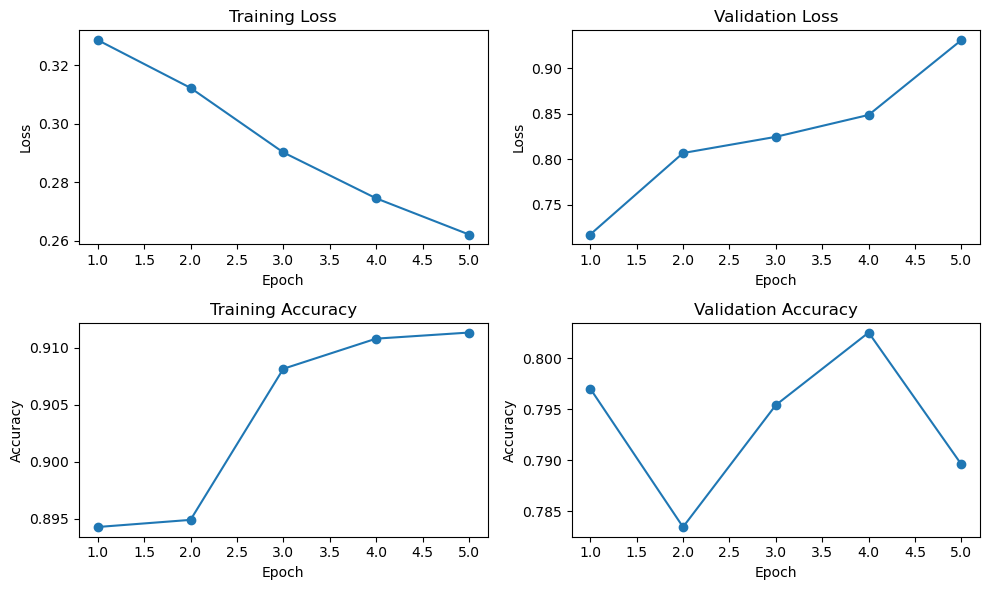

In [115]:
import matplotlib.pyplot as plt

epochs = range(1, len(TL) + 1)

fig, axs = plt.subplots(2, 2, figsize=(10, 6))  # reduced size

# Training Loss
axs[0, 0].plot(epochs, TL, marker="o")
axs[0, 0].set_title("Training Loss")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Loss")

# Validation Loss
axs[0, 1].plot(epochs, VL, marker="o")
axs[0, 1].set_title("Validation Loss")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Loss")

# Training Accuracy
axs[1, 0].plot(epochs, TA, marker="o")
axs[1, 0].set_title("Training Accuracy")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Accuracy")

# Validation Accuracy
axs[1, 1].plot(epochs, VA, marker="o")
axs[1, 1].set_title("Validation Accuracy")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()


### Final evaluation

In [90]:
yt, yp, prob = evaluate_with_probs(test_loader)


### Overall matrix



In [92]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

overall_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [
        accuracy_score(yt, yp),
        precision_score(yt, yp, average="macro", zero_division=0),
        recall_score(yt, yp, average="macro", zero_division=0),
        f1_score(yt, yp, average="macro", zero_division=0)
    ]
})
overall_df


,Metric,Value
0,Accuracy,0.789575
1,Precision,0.615433
2,Recall,0.672007
3,F1-score,0.613531


### Confusion matrix

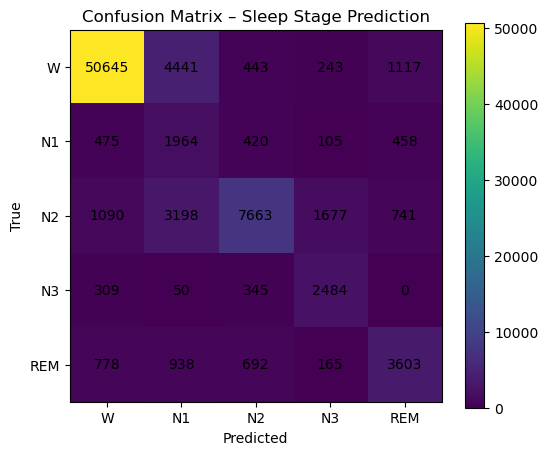

In [93]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

stage_names = ["W","N1","N2","N3","REM"]
cm = confusion_matrix(yt, yp)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.colorbar()
plt.xticks(range(5), stage_names)
plt.yticks(range(5), stage_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Sleep Stage Prediction")

for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


### Automatic labelling

In [94]:
inv_label_map = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}
pred_labels = [inv_label_map[int(p)] for p in yp]

pred_labels[:50]


['W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W',
 'W']

### Confidence score

In [95]:
import numpy as np

# confidence score = max softmax probability
conf = prob.max(axis=1)

# predicted class index
pred_class = prob.argmax(axis=1)


In [96]:
inv_label_map = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}

pred_stage = [inv_label_map[int(p)] for p in pred_class]
true_stage = [inv_label_map[int(t)] for t in yt]


In [104]:
for i in range(20):
    print(
        f"True: {true_stage[i]:>3} | "
        f"Pred: {pred_stage[i]:>3} | "
        f"Confidence: {conf[i]}"
    )


True:   W | Pred:   W | Confidence: 0.9999964237213135
True:   W | Pred:   W | Confidence: 0.9999959468841553
True:   W | Pred:   W | Confidence: 0.9999949932098389
True:   W | Pred:   W | Confidence: 0.9999961853027344
True:   W | Pred:   W | Confidence: 0.9999920129776001
True:   W | Pred:   W | Confidence: 0.9999912977218628
True:   W | Pred:   W | Confidence: 0.9999876022338867
True:   W | Pred:   W | Confidence: 0.9999929666519165
True:   W | Pred:   W | Confidence: 0.9999970197677612
True:   W | Pred:   W | Confidence: 0.9999973773956299
True:   W | Pred:   W | Confidence: 0.9999971389770508
True:   W | Pred:   W | Confidence: 0.9999971389770508
True:   W | Pred:   W | Confidence: 0.9999946355819702
True:   W | Pred:   W | Confidence: 0.9999924898147583
True:   W | Pred:   W | Confidence: 0.999994158744812
True:   W | Pred:   W | Confidence: 0.9999960660934448
True:   W | Pred:   W | Confidence: 0.9999936819076538
True:   W | Pred:   W | Confidence: 0.999993085861206
True:   W | 

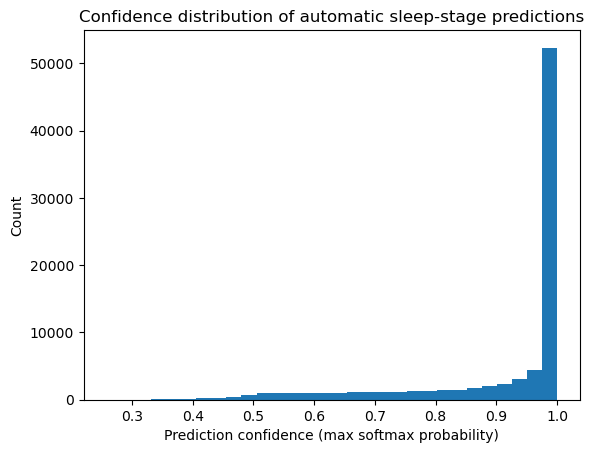

In [99]:
import matplotlib.pyplot as plt

plt.hist(conf, bins=30)
plt.xlabel("Prediction confidence (max softmax probability)")
plt.ylabel("Count")
plt.title("Confidence distribution of automatic sleep-stage predictions")
plt.show()


In [100]:
conf = prob.max(axis=1)

print("min/max confidence:", conf.min(), conf.max())
print("first 10 (6 decimals):", [f"{x:.6f}" for x in conf[:10]])


min/max confidence: 0.25756207 0.9999999
first 10 (6 decimals): ['0.999996', '0.999996', '0.999995', '0.999996', '0.999992', '0.999991', '0.999988', '0.999993', '0.999997', '0.999997']


In [101]:
print("prob[0] =", prob[0])
print("sum(prob[0]) =", prob[0].sum())


prob[0] = [9.9999642e-01 3.5134769e-06 2.1156195e-08 4.0944471e-08 7.5257217e-10]
sum(prob[0]) = 1.0


### XGBoost

Train XGBoost (epoch-level baseline)

In [107]:
import numpy as np
from xgboost import XGBClassifier

# XGBoost uses epoch-level rows (NOT sequences)
X_train_xgb = train_df[feature_cols].values
y_train_xgb = train_df["y"].values

X_test_xgb  = test_df[feature_cols].values
y_test_xgb  = test_df["y"].values

# optional: class imbalance handling via sample weights
counts = np.bincount(y_train_xgb, minlength=5)
class_w = counts.sum() / (5 * counts)          # balanced weights
sample_w = class_w[y_train_xgb]                # weight per row

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train_xgb, y_train_xgb, sample_weight=sample_w)

yp_xgb = xgb.predict(X_test_xgb)               # predicted class (0..4)
prob_xgb = xgb.predict_proba(X_test_xgb)       # probabilities (N,5)


### See what stage it is predicting (first 20)

In [108]:
inv_label_map = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}

pred_stage_xgb = [inv_label_map[int(p)] for p in yp_xgb]
true_stage_xgb = [inv_label_map[int(t)] for t in y_test_xgb]

conf_xgb = prob_xgb.max(axis=1)

for i in range(20):
    print(f"True={true_stage_xgb[i]:>3} | Pred={pred_stage_xgb[i]:>3} | conf={conf_xgb[i]:.6f}")


True=  W | Pred=  W | conf=0.876259
True=  W | Pred=  W | conf=0.847271
True=  W | Pred=  W | conf=0.975257
True=  W | Pred=  W | conf=0.937972
True=  W | Pred=  W | conf=0.981657
True=  W | Pred=  W | conf=0.860775
True=  W | Pred=  W | conf=0.980646
True=  W | Pred=  W | conf=0.984582
True=  W | Pred=  W | conf=0.940330
True=  W | Pred=  W | conf=0.989397
True=  W | Pred=  W | conf=0.987246
True=  W | Pred=  W | conf=0.952166
True=  W | Pred=  W | conf=0.990359
True=  W | Pred=  W | conf=0.992827
True=  W | Pred=  W | conf=0.948619
True=  W | Pred=  W | conf=0.944638
True=  W | Pred=  W | conf=0.958249
True=  W | Pred=  W | conf=0.953242
True=  W | Pred=  W | conf=0.970877
True=  W | Pred=  W | conf=0.985573


### Confusion matrix

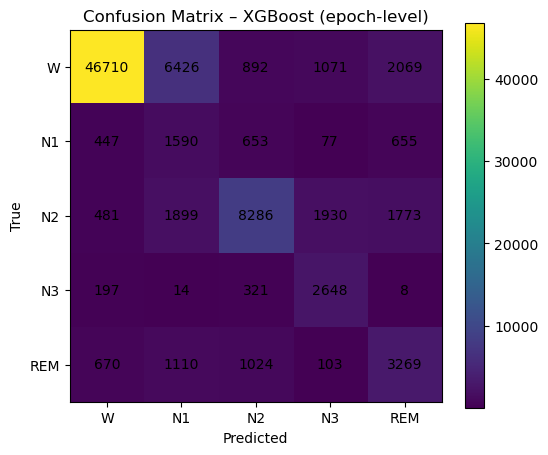

In [109]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

stage_names = ["W","N1","N2","N3","REM"]

cm_xgb = confusion_matrix(y_test_xgb, yp_xgb)

plt.figure(figsize=(6,5))
plt.imshow(cm_xgb)
plt.colorbar()
plt.xticks(range(5), stage_names)
plt.yticks(range(5), stage_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – XGBoost (epoch-level)")

for i in range(5):
    for j in range(5):
        plt.text(j, i, cm_xgb[i, j], ha="center", va="center")

plt.show()


In [110]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support

# overall
overall_xgb = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    "Value": [
        accuracy_score(y_test_xgb, yp_xgb),
        precision_score(y_test_xgb, yp_xgb, average="macro", zero_division=0),
        recall_score(y_test_xgb, yp_xgb, average="macro", zero_division=0),
        f1_score(y_test_xgb, yp_xgb, average="macro", zero_division=0),
    ]
})
overall_xgb

# per-class
prec, rec, f1, supp = precision_recall_fscore_support(y_test_xgb, yp_xgb, labels=[0,1,2,3,4], zero_division=0)

perclass_xgb = pd.DataFrame({
    "Stage": stage_names,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "Support": supp
})
perclass_xgb


,Stage,Precision,Recall,F1,Support
0,W,0.962994,0.817065,0.884048,57168
1,N1,0.144035,0.464641,0.219902,3422
2,N2,0.741410,0.576658,0.648738,14369
3,N3,0.454280,0.830615,0.587335,3188
4,REM,0.420504,0.529307,0.468674,6176


### Comparison LSTM and XGBoost

In [112]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["XGBoost (epoch-level)", "LSTM (sequence-level)"],
    "Accuracy": [
        accuracy_score(y_test_xgb, yp_xgb),
        accuracy_score(yt, yp)
    ],
    "Precision": [
        precision_score(y_test_xgb, yp_xgb, average="macro", zero_division=0),
        precision_score(yt, yp, average="macro", zero_division=0)
    ],
    "Recall": [
        recall_score(y_test_xgb, yp_xgb, average="macro", zero_division=0),
        recall_score(yt, yp, average="macro", zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test_xgb, yp_xgb, average="macro", zero_division=0),
        f1_score(yt, yp, average="macro", zero_division=0)
    ],
})
comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost (epoch-level),0.741233,0.544645,0.643657,0.561739
1,LSTM (sequence-level),0.789575,0.615433,0.672007,0.613531


# Automatic Sleep Stage Labeling Using Temporal Deep Learning Models

## Abstract
Automatic sleep staging is a fundamental task in sleep research and clinical diagnostics, traditionally performed through manual scoring of polysomnography recordings at fixed time intervals. This study presents an automatic sleep stage labeling system based on physiological features derived from EEG, EOG, and EMG signals. Sleep staging is formulated as a multi-class classification problem at the **30-second epoch level**, following standard clinical scoring protocols. A sequence-based Long Short-Term Memory (LSTM) model is proposed to capture temporal dependencies across consecutive epochs and is compared against a non-temporal machine learning baseline (XGBoost). Experimental results demonstrate that incorporating temporal context significantly improves classification performance and produces confidence estimates that align with known physiological uncertainties in sleep architecture.

---

## I. Introduction
Sleep is a dynamic physiological process characterized by structured transitions among discrete stages, typically scored in **30-second epochs** according to established clinical guidelines. Manual sleep staging is time-consuming, subjective, and prone to inter-scorer variability, motivating the development of reliable automatic sleep staging systems.

Recent approaches to automatic sleep staging have employed machine learning and deep learning techniques using either handcrafted features or raw physiological signals. However, many models treat sleep epochs as independent samples, ignoring the strong temporal dependencies inherent in sleep architecture. Since sleep stages evolve gradually over time, explicitly modeling temporal context is expected to yield more physiologically consistent predictions.

In this work, we investigate automatic sleep stage labeling using **epoch-level physiological features**, focusing on the role of temporal modeling. A sequence-based LSTM model operating on consecutive **30-second epochs** is compared to an epoch-level XGBoost baseline that does not exploit temporal information. In addition to standard classification metrics, model confidence scores are analyzed to assess prediction reliability and uncertainty.

---

## II. Dataset Description
Experiments were conducted using the Sleep-EDF database, which contains whole-night polysomnography (PSG) recordings including EEG, EOG, and chin EMG signals, together with expert-scored hypnograms. Sleep stages in the dataset are annotated at a **fixed temporal resolution of 30 seconds**, meaning that each epoch corresponds to a non-overlapping 30-second window of physiological activity.

Each 30-second epoch is assigned a single sleep stage label. In this study, sleep staging is treated as a five-class classification task with the following labels:
- Wake (W)
- N1
- N2
- N3
- REM

---

## III. Data Preparation and Feature Processing
Raw physiological signals were represented at the **30-second epoch level** using engineered statistical features extracted from EEG, EOG, and EMG channels. Each row in the dataset corresponds to **one 30-second epoch** and contains numeric features such as mean, standard deviation, and root mean square (RMS) values computed over that epoch.

Categorical sleep stage labels were mapped to integer class indices, and invalid or ambiguous labels were removed. To prevent information leakage, the dataset was split into training and testing sets **by recording ID**, ensuring that epochs from the same subject did not appear in both sets.

Non-physiological and identifier variables—including recording identifiers, file names, epoch indices, and timestamp fields—were excluded from the feature set. Feature scaling was performed using z-score normalization:

$$
x' = \frac{x - \mu}{\sigma}
$$

where \( \mu \) and \( \sigma \) were computed using only the training data and applied consistently to both training and testing sets.

---

## IV. Sequence Construction and Temporal Context
Sleep stages exhibit strong temporal structure, with transitions governed by physiological rules rather than random fluctuations. To capture this dependency, consecutive **30-second epochs** were grouped into fixed-length sequences of \( T \) epochs.

Since each epoch represents 30 seconds, each sequence spans a temporal window of:

$$
30T \text{ seconds}
$$

For example, with \( T = 10 \), the model observes 10 consecutive epochs corresponding to 300 seconds (5 minutes) of prior physiological activity. Each sequence is assigned the label of its final epoch, reflecting the task of predicting the current sleep stage given recent history.

Formally, for epoch-level feature vectors \( \{x_1, x_2, \dots, x_n\} \), each sequence is defined as:

$$
X_i = \{x_{i-T+1}, x_{i-T+2}, \ldots, x_i\}
$$

with the associated label:

$$
y_i = \text{label}(x_i)
$$

This formulation produces inputs of shape \( (\text{samples}, \text{time steps}, \text{features}) \), which is standard for recurrent neural networks.

---

## V. Models

### A. LSTM Sequence-Level Model
A multi-layer Long Short-Term Memory (LSTM) network was used to model temporal dependencies across sequences of consecutive 30-second epochs. The LSTM processes each sequence and outputs a hidden representation at the final time step, which is passed through a fully connected layer to predict the sleep stage.

The model outputs class logits, which are converted to probabilities using the softmax function:

$$
P(y = k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{5} e^{z_j}}
$$

The predicted label is:

$$
\hat{y} = \arg\max_k P(y = k \mid x)
$$

To address class imbalance, a class-weighted cross-entropy loss was employed:

$$
\mathcal{L} = -\sum_{k=1}^{5} w_k \, y_k \log(P(y = k \mid x))
$$

where \( w_k \) denotes the weight associated with class \( k \).

---

### B. XGBoost Epoch-Level Baseline
As a non-temporal baseline, an XGBoost classifier was trained on individual **30-second epochs**, treating each epoch independently without temporal context. The same feature set and training/testing split were used, enabling a direct comparison between temporal and non-temporal modeling approaches.

---

## VI. Training Dynamics
Training curves show a monotonic decrease in training loss and a corresponding increase in training accuracy. Validation loss increases after early epochs, indicating overfitting, which is common in sleep staging tasks due to class imbalance and label ambiguity. Validation accuracy peaks before the final epoch, reinforcing the importance of validation-based model selection.

---

## VII. Evaluation Metrics
Models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrices for per-class analysis

---

## VIII. Quantitative Results

| Model                     | Accuracy | Precision | Recall | F1 Score |
|--------------------------|----------|-----------|--------|----------|
| XGBoost (epoch-level)    | 0.741    | 0.545     | 0.644  | 0.562    |
| LSTM (sequence-level)    | 0.790    | 0.615     | 0.672  | 0.614    |

The LSTM model consistently outperforms the epoch-level baseline, demonstrating the benefit of incorporating temporal context across consecutive 30-second epochs.

---

## IX. Confusion Matrix Analysis
The LSTM model shows strong performance for Wake, N2, and N3, with clear diagonal dominance in the confusion matrix. Most misclassifications occur between adjacent sleep stages, particularly involving N1 and REM, which are known to be physiologically ambiguous even for expert scorers.

Compared to XGBoost, the LSTM produces smoother predictions with reduced fragmentation, reflecting more realistic sleep-stage transitions.

---

## X. Confidence Score Analysis
For each prediction, a confidence score was computed as the maximum softmax probability:

$$
\text{Confidence}(x) = \max_k P(y = k \mid x)
$$

High confidence values are observed for stable stages such as Wake and N2, while lower confidence values occur near stage transitions and for ambiguous stages such as N1 and REM. This behavior aligns with known properties of sleep architecture and expert uncertainty.

Confidence analysis enables identification of uncertain predictions, supports human-in-the-loop review, and improves the safety of automated sleep staging systems.

---

## Automatic Sleep Stage Labeling (Inference Mode)

After training, the LSTM model is used in an **automatic labeling (inference) mode**. In this setting, the model receives only physiological feature sequences derived from EEG, EOG, and EMG signals, without access to expert sleep-stage annotations. For each sequence of consecutive 30-second epochs, the trained model predicts the sleep stage of the final epoch, thereby generating an automatically labeled hypnogram.

Formally, given a trained model \( f(\cdot) \) and an input sequence:

$$
X_i = \{x_{i-T+1}, x_{i-T+2}, \ldots, x_i\}
$$

the predicted sleep stage is obtained as:

$$
\hat{y}_i = \arg\max_k P(y = k \mid X_i)
$$

This process enables **fully automatic sleep stage labeling** across an entire recording by sliding the prediction window forward one epoch at a time. The resulting output is a complete sequence of predicted sleep stages at **30-second resolution**, directly comparable to expert-scored hypnograms.

Importantly, expert labels are used **only during training and evaluation**, and are not required during inference. This demonstrates the feasibility of deploying the proposed model as an automated sleep staging system.

---

## XI. Conclusion

This study presented a fully automatic sleep stage labeling system based on physiological features derived from EEG, EOG, and EMG signals. Sleep staging was formulated at the standard clinical resolution of 30-second epochs, and temporal dependencies were explicitly modeled using a sequence-based LSTM architecture.

Compared to an epoch-level non-temporal baseline, the LSTM model achieved superior performance across accuracy, precision, recall, and F1-score, demonstrating the importance of temporal context in sleep-stage classification. Misclassifications primarily occurred between adjacent and physiologically ambiguous stages, consistent with known challenges in manual sleep scoring.

Importantly, once trained, the proposed model operates in a fully automatic inference mode, requiring no expert annotations to generate sleep-stage labels for unseen recordings. The inclusion of confidence scores further enables uncertainty-aware predictions, supporting human-in-the-loop review and safer deployment in clinical and research settings.

Overall, the results indicate that sequence-based deep learning provides an effective and interpretable framework for automatic sleep staging, closely aligned with expert scoring practices and the temporal structure of human sleep.

